In [17]:
import pandas as pd

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv(r"../data/raw/sales.csv")

In [19]:
df.isnull().sum()

Row ID+O6G3A1:R6    0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Profit              0
Payment Mode        0
dtype: int64

How big this data is 

In [20]:
df.shape[0]  # Number of rows
df.shape[1]  # Number of columns

20

In [21]:
# how does the data look like 
df.sample(5)

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Payment Mode
1663,3502,CA-2019-108616,2019-09-29,2019-10-03,Standard Class,JK-15730,Joe Kamberova,Consumer,United States,Mobile,Alabama,South,OFF-AR-10001149,Office Supplies,Art,"Sanford Colorific Colored Pencils, 12/Box",25.92,9,7.7760,COD
5330,427,CA-2020-149160,2020-11-23,2020-11-26,Second Class,JM-15265,Janet Molinari,Corporate,United States,Canton,Michigan,Central,OFF-BI-10001543,Office Supplies,Binders,GBC VeloBinder Manual Binding System,297.92,8,138.2016,Online
5605,7518,US-2020-167920,2020-12-09,2020-12-12,Second Class,JL-15835,John Lee,Consumer,United States,Richmond,Kentucky,South,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,166.45,5,48.3285,COD
1331,5429,CA-2019-113096,2019-09-02,2019-09-04,First Class,SZ-20035,Sam Zeldin,Home Office,United States,San Francisco,California,West,OFF-ST-10003455,Office Supplies,Storage,"Tenex File Box, Personal Filing Tote with Lid,...",46.53,3,12.0978,Cards
1383,9930,CA-2019-129630,2019-09-04,2019-09-04,Same Day,IM-15055,Ionia McGrath,Consumer,United States,San Francisco,California,West,TEC-CO-10003763,Technology,Copiers,Canon PC1060 Personal Laser Copier,2799.96,5,944.9865,Cards


In [37]:
# what is the datatypes of cols?
df.dtypes

Row ID+O6G3A1:R6             int64
order_id                    object
order_date          datetime64[ns]
ship_date           datetime64[ns]
ship_mode                 category
customer_id                 object
customer_name               object
segment                   category
country                   category
city                        object
state                       object
region                    category
product_id                  object
category                  category
sub_category                object
product_name                object
sales                      float64
quantity                     int64
profit                     float64
payment_mode              category
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
dtype: object

In [23]:
df= df.rename(columns={'Order ID':"order_id", 'Order Date':"order_date", 'Ship Date':'ship_date', 'Ship Mode':'ship_mode',
        'Customer ID':'customer_id', 'Customer Name':'customer_name', 'Segment':'segment', 'Country':'country', 'City':'city', 'State':'state',
        'Region':'region', 'Product ID':'product_id', 'Category':'category', 'Sub-Category':'sub_category', 'Product Name':'product_name',
        'Sales':'sales', 'Quantity':'quantity', 'Profit':'profit', 'Payment Mode':'payment_mode', 'avg profit':'avg_profit',
        'Profit status':'profit_status', 'Days Between Delivery':'days_between_delivery', 'Avg delivery date':'avg_delivery_date',
        'Delivery_remarks':'delivery_remark'})

In [29]:
# correct date formats
df["order_date"] = pd.to_datetime(df["order_date"],format='mixed', errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"],format='mixed', errors="coerce")

In [38]:
# identify categorical columns and convert into category datatype
for col in df.columns:
    if df[col].nunique() < 10:   # we maka a assumption that if a column has less than 10 unique values, it is a categorical column
        print(col)
        df[col] = df[col].astype("category")



ship_mode
segment
country
region
category
payment_mode


In [30]:
# what are the missing data
df.isnull().sum()

Row ID+O6G3A1:R6    0
order_id            0
order_date          0
ship_date           0
ship_mode           0
customer_id         0
customer_name       0
segment             0
country             0
city                0
state               0
region              0
product_id          0
category            0
sub_category        0
product_name        0
sales               0
quantity            0
profit              0
payment_mode        0
Order Date          0
Ship Date           0
dtype: int64

In [31]:
# is there any duplicate if how many
df.duplicated().sum()


np.int64(0)

In [32]:
# summary of data
df.describe()

,Row ID+O6G3A1:R6,order_date,ship_date,sales,quantity,profit,Order Date,Ship Date
count,5901.000000,5901,5901,5901.000000,5901.000000,5901.000000,5901,5901
mean,5022.422471,2020-02-29 01:53:57.620742144,2020-03-04 00:08:47.097102336,265.345589,3.781901,29.700408,2020-02-29 01:53:57.620742144,2020-03-04 00:08:47.097102336
min,1.000000,2019-01-01 00:00:00,2019-01-05 00:00:00,0.836000,1.000000,-6599.978000,2019-01-01 00:00:00,2019-01-05 00:00:00
25%,2486.000000,2019-09-11 00:00:00,2019-09-15 00:00:00,71.976000,2.000000,1.795500,2019-09-11 00:00:00,2019-09-15 00:00:00
50%,5091.000000,2020-03-16 00:00:00,2020-03-19 00:00:00,128.648000,3.000000,8.502500,2020-03-16 00:00:00,2020-03-19 00:00:00
75%,7456.000000,2020-09-14 00:00:00,2020-09-16 00:00:00,265.170000,5.000000,28.615000,2020-09-14 00:00:00,2020-09-16 00:00:00
max,9994.000000,2020-12-31 00:00:00,2021-01-05 00:00:00,9099.930000,14.000000,8399.976000,2020-12-31 00:00:00,2021-01-05 00:00:00
std,2877.977184,NaN,NaN,474.260645,2.212917,259.589138,NaN,NaN


In [33]:
# how is the correlation between the numerical cols
df.corr(numeric_only=True)

,Row ID+O6G3A1:R6,sales,quantity,profit
Row ID+O6G3A1:R6,1.000000,0.019204,0.012414,0.018891
sales,0.019204,1.000000,0.202420,0.325915
quantity,0.012414,0.202420,1.000000,0.074761
profit,0.018891,0.325915,0.074761,1.000000


#####################UNIVARIATE Analysis##########################################

In [66]:
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

# Integer columns
integer_cols = df.select_dtypes(include=['int64',"float64" ,'int32']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Integer Columns:", integer_cols)

Categorical Columns: ['ship_mode', 'segment', 'country', 'region', 'category', 'payment_mode']
Integer Columns: ['Row ID+O6G3A1:R6', 'sales', 'quantity', 'profit']


A count plot is used in a project to visualize the frequency of different categories in a dataset. It helps us understand how many times each category appears in a column.


The purpose of counting (in categorical data analysis) is to understand how often each category occurs in your dataset.

why ? 
To understand distribution
To detect imbalance
To find most and least frequent values
To summarize data quickly
To support visualization

Counting is used to find the frequency of each category in a variable, helping us understand distribution, detect imbalance, and summarize categorical data effectively.






################# for categorical columns #################################

segment
Consumer       2997
Corporate      1774
Home Office    1130
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Segments')

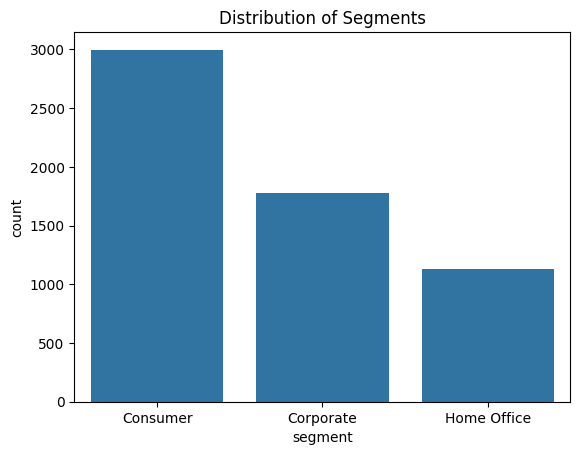

In [60]:
print(df['segment'].value_counts())
sns.countplot(data=df, x="segment")
plt.title("Distribution of Segments")

payment_mode
COD       2453
Online    2164
Cards     1284
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Payment Modes')

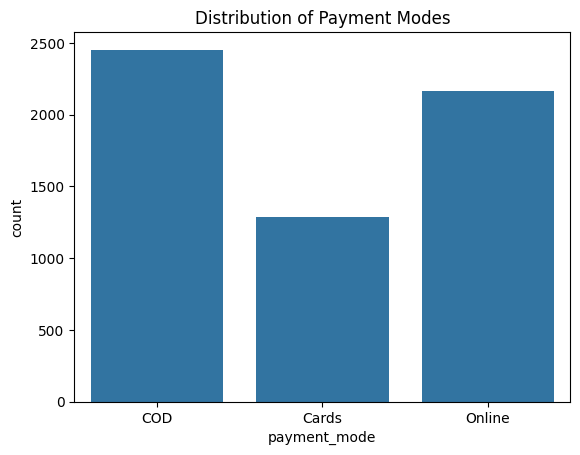

In [58]:
print(df['payment_mode'].value_counts())
sns.countplot(x=df['payment_mode'])
plt.title("Distribution of Payment Modes")

region
West       1901
East       1688
Central    1381
South       931
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Regions')

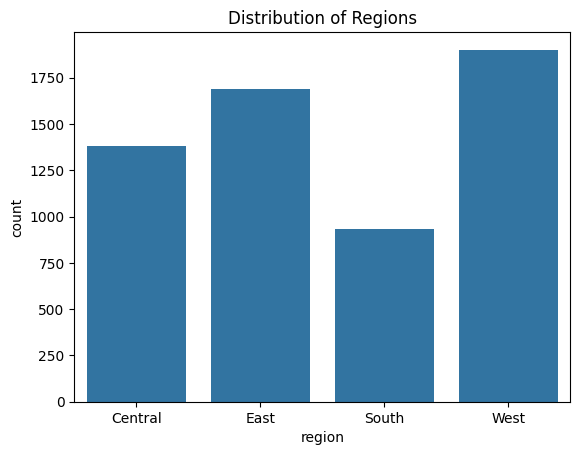

In [64]:
print(df['region'].value_counts())
sns.countplot(data=df, x="region")
plt.title("Distribution of Regions")


country
United States    5901
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Countries')

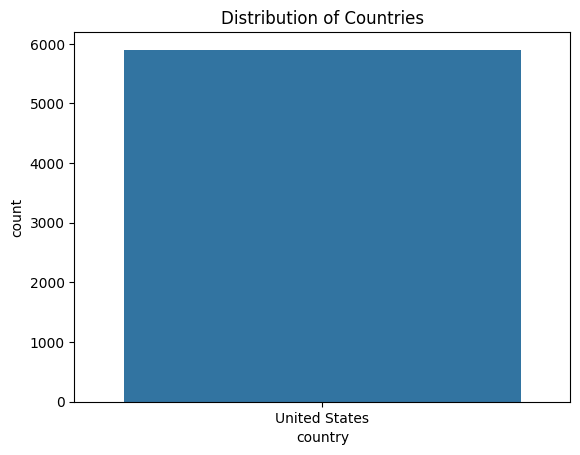

In [63]:

print(df['country'].value_counts())
sns.countplot(x=df['country'])
plt.title("Distribution of Countries")

category
Office Supplies    3569
Furniture          1249
Technology         1083
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Categories')

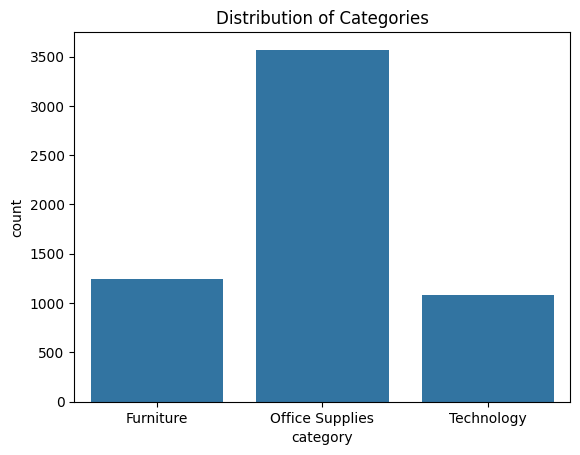

In [62]:

print(df['category'].value_counts())
sns.countplot(data=df, x="category")
plt.title("Distribution of Categories")

ship_mode
Standard Class    3451
Second Class      1147
First Class        959
Same Day           344
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Ship Modes')

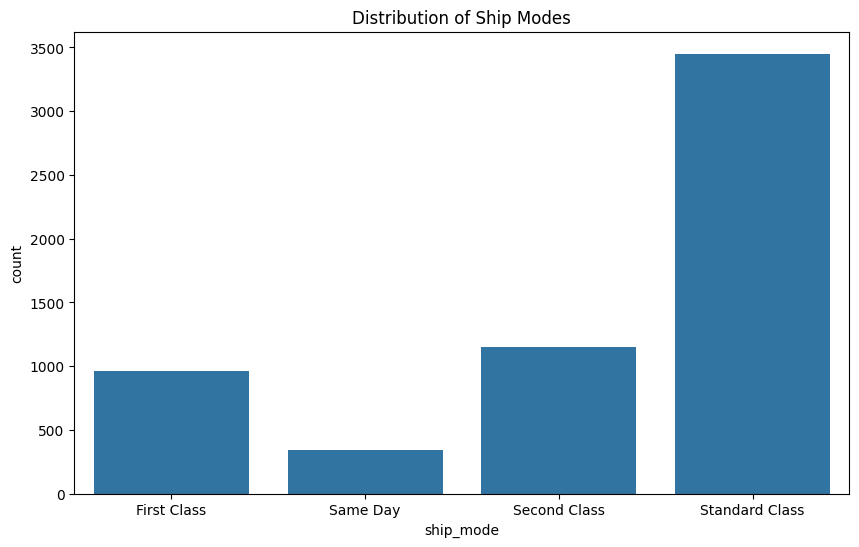

In [61]:
plt.figure(figsize=(10, 6))
print(df['ship_mode'].value_counts())
sns.countplot(x=df['ship_mode'])
plt.title("Distribution of Ship Modes")

##########################  For numerical columns #######################################

##########################   Sales ######################################

Text(0.5, 1.0, 'Distribution of Sales')

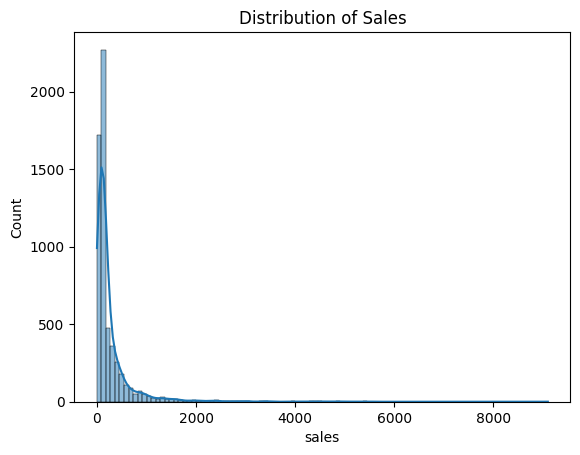

In [72]:
summary=df['sales'].describe()
sns.histplot(df['sales'], bins=100, kde=True)
plt.title("Distribution of Sales")

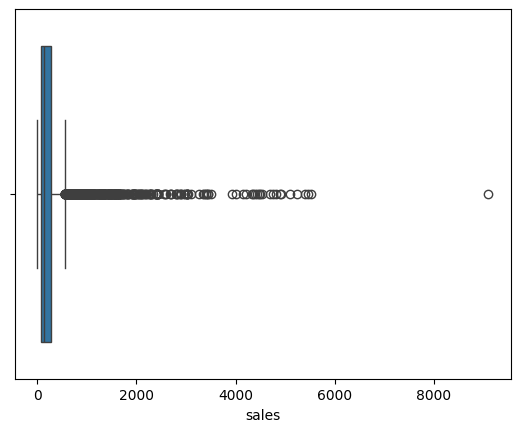

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['sales'], color='skyblue')
plt.title("Boxplot of Sales", fontsize=14, fontweight='bold')
plt.xlabel("Sales Amount", fontsize=12)
plt.show()